# **Project Name -** **Gold Price Prediction**

---
Project Type - **Time Series Forecasting**

Project Source - **Kaggle**

Contributors - **Sagar Jain**


# **Project Overview**

**Problem Statement**

Gold prices fluctuate due to market demand, economic conditions, inflation, and global uncertainty. Understanding historical price patterns can help in identifying trends and predicting future price movements.

The objective of this project is to analyze historical gold price data, perform exploratory data analysis to identify patterns and trends, and build time series forecasting models to predict future gold prices. The project will use statistical techniques and machine learning models to understand price behavior and improve forecasting accuracy.

**Project Summary**

**Github Link**

https://github.com/Sagarjain93/Machine-Learning-Portfolio/tree/main/03_ML_Practice/Gold_Price_Prediction_Forecasting

# **Import Required Libraries**

In [25]:
# ============================================
# DATA MANIPULATION LIBRARIES
# ============================================

import pandas as pd                # For data manipulation and analysis
import numpy as np                 # For numerical operations


# ============================================
# DATA VISUALIZATION LIBRARIES
# ============================================

import matplotlib.pyplot as plt    # Basic plotting library
import seaborn as sns              # Advanced statistical visualizations

# Setting visualization style
sns.set(style="whitegrid")


# ============================================
# TIME SERIES ANALYSIS LIBRARIES
# ============================================

from statsmodels.tsa.stattools import adfuller     # Augmented Dickey-Fuller test (stationarity check)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # ACF and PACF plots
from statsmodels.tsa.seasonal import seasonal_decompose         # Decompose time series


# ============================================
# STATISTICAL TESTING
# ============================================

from scipy import stats            # For hypothesis testing


# ============================================
# MACHINE LEARNING LIBRARIES
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================
# MACHINE LEARNING MODELS
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# ============================================
# TIME SERIES MODELS
# ============================================

from statsmodels.tsa.arima.model import ARIMA


# ============================================
# IGNORE WARNINGS
# ============================================

import warnings
warnings.filterwarnings("ignore")

# **Data Collection & Data Loading**

**Clone GitHub Repository in Colab**

In [1]:
# Clone your GitHub repository into the Colab environment
!git clone https://github.com/Sagarjain93/Machine-Learning-Portfolio.git

Cloning into 'Machine-Learning-Portfolio'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 600 (delta 103), reused 15 (delta 15), pack-reused 441 (from 2)
Receiving objects: 100% (600/600), 18.69 MiB | 11.30 MiB/s, done.
Resolving deltas: 100% (356/356), done.


**Navigate to Dataset Folder**

In [2]:
# List files inside the raw data folder
!ls Machine-Learning-Portfolio/03_ML_Practice/Gold_Price_Prediction_Forecasting/01_raw_data

gold_price_raw_data.csv


**Load the CSV File**

In [4]:
# Define the file path to the dataset inside the cloned repository
file_path = "Machine-Learning-Portfolio/03_ML_Practice/Gold_Price_Prediction_Forecasting/01_raw_data/gold_price_raw_data.csv"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)


# **Initial Data Exploration**

**Preview the dataset**

In [5]:
# Display the first 5 rows of the dataset
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77


In [6]:
# Display the last 5 rows of the dataset
df.tail()

,Date,Price,Open,High,Low,Volume,Chg%
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3102,2014-01-02,29975,29678,30050,29678,3140,1.47
3103,2014-01-01,29542,29435,29598,29340,2930,0.25


**Check Dataset Shape**

In [12]:
# Check number of rows and columns in the dataset
print(f"The dataset has {df.shape[0]} rows")
print(f"The dataset has {df.shape[1]} columns")

The dataset has 3104 rows
The dataset has 7 columns


**Column Names**

In [13]:
df.columns

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Chg%'], dtype='object')

**Dataset Information**

In [14]:
# Get information about data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB


**Summary Statistics**

In [15]:
# Generate summary statistics for numerical columns
df.describe()

,Price,Open,High,Low,Volume,Chg%
count,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000,3104.000000
mean,46263.721972,46250.184278,46515.665271,45997.234214,14855.159472,0.052957
std,22230.385519,22191.261855,22364.944669,22053.596236,14197.123722,0.854364
min,24545.000000,24583.000000,24635.000000,24470.000000,0.000000,-5.980000
25%,29358.750000,29331.500000,29462.750000,29214.000000,6780.000000,-0.370000
50%,38832.500000,38902.500000,39083.000000,38626.500000,11520.000000,0.060000
75%,54970.250000,54900.000000,55211.250000,54730.500000,18602.500000,0.480000
max,137789.000000,137628.000000,138300.000000,136300.000000,149474.000000,5.300000


**Check Missing Values**

In [16]:
# Check number of missing values in each column

df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Volume,0
Chg%,0


**Check Duplicate Rows**

In [17]:
# Check if duplicate rows exist in the dataset

df.duplicated().sum()

np.int64(0)

### **Observations from Initial Data Exploration**

- The dataset contains **3104 observations** and **7 features**.
- There are **no missing values** present in the dataset.
- No **duplicate rows** were found.
- Most columns have appropriate numeric data types.
- The **Date column is currently stored as an object and needs to be converted to datetime format** for proper time series analysis.

# **Data Cleaning**

**1. Convert Date Column to Datetime**

In [18]:
# Convert the 'Date' column from object to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check the datatype again to confirm conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3104 non-null   datetime64[ns]
 1   Price   3104 non-null   int64         
 2   Open    3104 non-null   int64         
 3   High    3104 non-null   int64         
 4   Low     3104 non-null   int64         
 5   Volume  3104 non-null   int64         
 6   Chg%    3104 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 169.9 KB


**2. Sort Dataset by Date**

In [19]:
# Sort the dataset by Date in ascending order
df = df.sort_values(by="Date")

# Display first few rows after sorting
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
3103,2014-01-01,29542,29435,29598,29340,2930,0.25
3102,2014-01-02,29975,29678,30050,29678,3140,1.47
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83
3100,2014-01-04,29279,29279,29279,29279,0,-1.51
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55


**3. Reset Index**

In [20]:
# Reset the index after sorting
df = df.reset_index(drop=True)

# Display first few rows
df.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2014-01-01,29542,29435,29598,29340,2930,0.25
1,2014-01-02,29975,29678,30050,29678,3140,1.47
2,2014-01-03,29727,30031,30125,29539,3050,-0.83
3,2014-01-04,29279,29279,29279,29279,0,-1.51
4,2014-01-06,29119,29300,29395,29051,24380,-0.55


**4. Set Date as Index**

In [21]:
# Set Date column as the dataframe index
df.set_index("Date", inplace=True)

# Display first few rows
df.head()

,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


**5. Final Check**

In [22]:
# Check dataset structure after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3104 entries, 2014-01-01 to 2026-01-02
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3104 non-null   int64  
 1   Open    3104 non-null   int64  
 2   High    3104 non-null   int64  
 3   Low     3104 non-null   int64  
 4   Volume  3104 non-null   int64  
 5   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 169.8 KB


In [23]:
df.head()

,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


### **Data Cleaning Observations**

- The **Date column was converted to datetime format** to enable time series operations.
- The dataset was **sorted chronologically** to maintain correct temporal order.
- The **Date column was set as the index**, which allows easier time-based analysis.
- Some dates are missing because **financial markets are closed on weekends and holidays**, which is expected for trading datasets.

# **EDA**

## **UNIVARIATE**

### **Chart 1 — Distribution of Gold Prices**

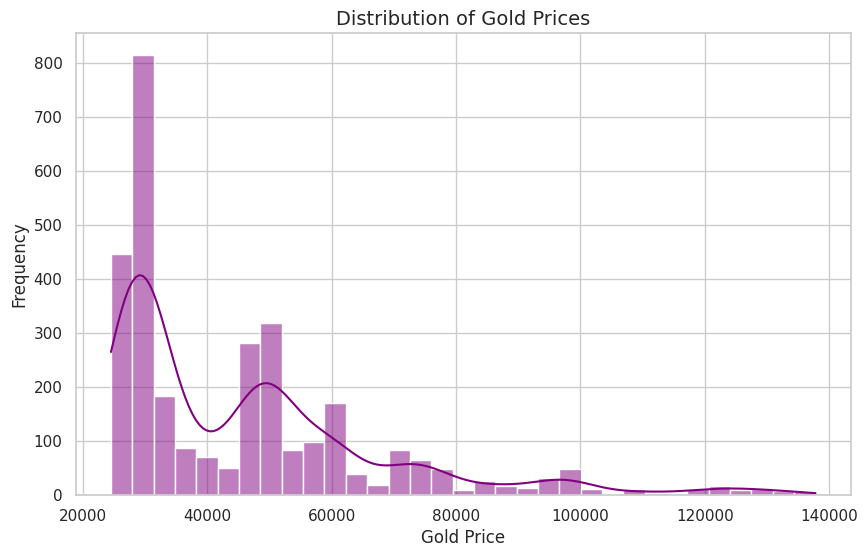

In [26]:
# Chart 1: Distribution of Gold Prices

# This chart helps understand how gold prices are distributed in the dataset

plt.figure(figsize=(10,6))  # Set figure size

# Histogram with KDE curve to visualize distribution
sns.histplot(df["Price"], kde=True, color="purple")

# Chart title and labels
plt.title("Distribution of Gold Prices", fontsize=14)
plt.xlabel("Gold Price")
plt.ylabel("Frequency")

# Display chart
plt.show()

#### **Why this chart is used**

A Histogram with KDE is used to understand the distribution of a numerical variable.

It helps us see:

*  How gold prices are spread across the dataset

*  Whether the data is normal, left-skewed, or right-skewed

*  Whether there are multiple peaks or clusters

This is important before building models because skewed distributions can affect statistical assumptions.

#### **Insight from the chart**

From the histogram we can observe:

*  The distribution is right-skewed (positively skewed).

*  Most gold prices are concentrated roughly between: ₹25,000 – ₹60,000

*  There are fewer observations at very high prices, which stretch the tail toward ₹120,000+.

*  The dataset seems to contain multiple peaks, suggesting different price regimes over time.

This happens because gold prices increase significantly across years.

#### **Business Insight**

**Positive Insight**

Gold prices show a long-term upward trend, meaning the asset has appreciated significantly over time. This reinforces gold's reputation as a strong long-term investment and hedge against inflation.

**Market Insight**

The right skew suggests that recent years contain much higher prices compared to older years, which is expected due to economic factors like inflation, demand, and global uncertainty.

### **Chart 2: Boxplot of Gold Prices**

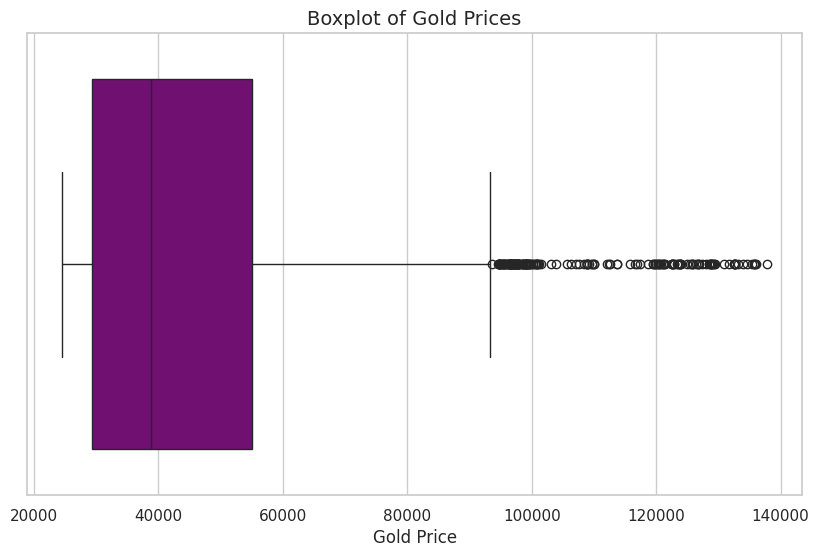

In [27]:
# Chart 2: Boxplot of Gold Prices

# This chart helps detect outliers and understand the spread of gold prices

plt.figure(figsize=(10,6))  # set figure size

# Boxplot visualization
sns.boxplot(x=df["Price"], color="purple")

# Chart title and labels
plt.title("Boxplot of Gold Prices", fontsize=14)
plt.xlabel("Gold Price")

# Display the chart
plt.show()

#### **Why this chart is used**

A Boxplot is used to understand:

*  Spread of the data

*  Median value

*  Interquartile range (IQR)

*  Presence of outliers

Unlike histograms, boxplots clearly highlight extreme values in the dataset.

For financial datasets like gold prices, this helps us detect price spikes or unusual market movements.

#### **Insight from the chart**

From the boxplot we can observe:

*  The median gold price appears around: ~ ₹38,000 – ₹40,000

*  The interquartile range (IQR) roughly lies between: ₹30,000 – ₹55,000

*  Meaning 50% of gold prices fall within this range.

*  There are many outliers on the right side of the plot.

*  These represent very high gold prices observed in later years.

*  The distribution again confirms right skewness, which we already saw in Chart 1.

#### **Business Insight**

**Positive Insight**

*  The presence of many high-value outliers indicates that gold prices increased significantly in later years, reflecting strong long-term growth.

*  This supports gold's role as a safe-haven asset during inflation and economic uncertainty.

**Market Behavior Insight**

*  These "outliers" are not errors.
*  They represent structural market growth over time.

* So we should NOT remove these values, because they contain important financial information.

### **Chart 3: Distribution of Trading Volume**

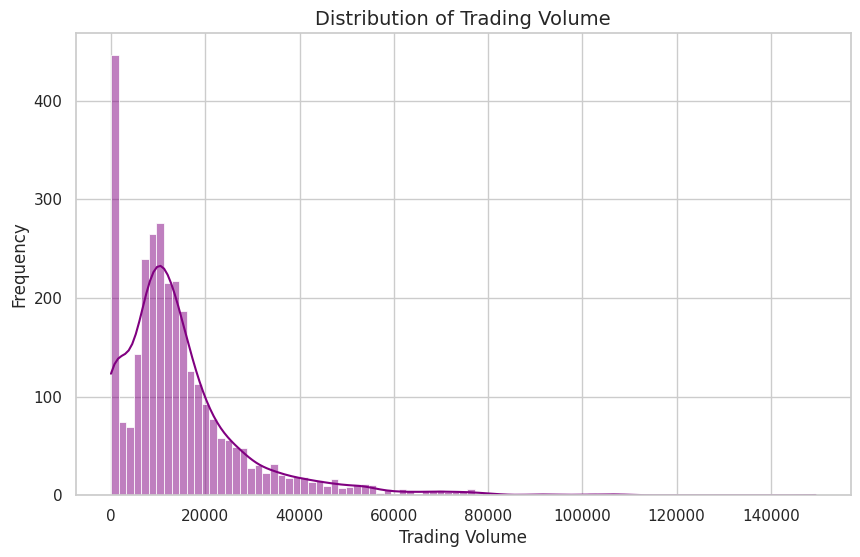

In [28]:
# Chart 3: Distribution of Trading Volume

# This chart helps understand how trading activity (volume)
# is distributed across the dataset and whether trading is consistent or irregular.

plt.figure(figsize=(10,6))  # Set figure size

# Histogram with KDE to visualize distribution of trading volume
sns.histplot(df["Volume"], kde=True, color="purple")

# Chart title and labels
plt.title("Distribution of Trading Volume", fontsize=14)
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")

# Display the chart
plt.show()

#### **Why this chart is used**

*  A Histogram with KDE is used to understand the distribution of trading activity in the market.

*  Trading Volume represents the number of contracts traded on a given day.
Analyzing its distribution helps us understand:

    *  Whether trading activity is consistent or highly volatile

    *  Whether there are days with extremely high trading activity

    *  How frequently high-volume events occur

*  This is important because volume often reflects market sentiment and investor participation.

#### **Insight from the chart**

From the chart we can observe:

*  The distribution is heavily right-skewed.

*  Most trading volume is concentrated roughly between: 0 – 20,000

*  There are few days with extremely high volume, extending up to around: 150,000

*  The large spike near very low volumes suggests that many days have relatively low trading activity.


#### **Business Insight**

**Market Insight**

*  The gold market generally experiences moderate daily trading activity, with occasional spikes in trading volume.

*  These spikes may correspond to:

    *  Major economic announcements

    *  Geopolitical events

    *  Inflation concerns

    *  market volatility periods

    *  Risk / Opportunity Insight

*  High-volume spikes often indicate strong market reactions and may signal important turning points or strong trends in gold prices.

*  Traders and analysts often monitor volume spikes to identify potential buying or selling pressure in the market.

### **Chart 4: Distribution of Daily Percentage Change (Chg%)**

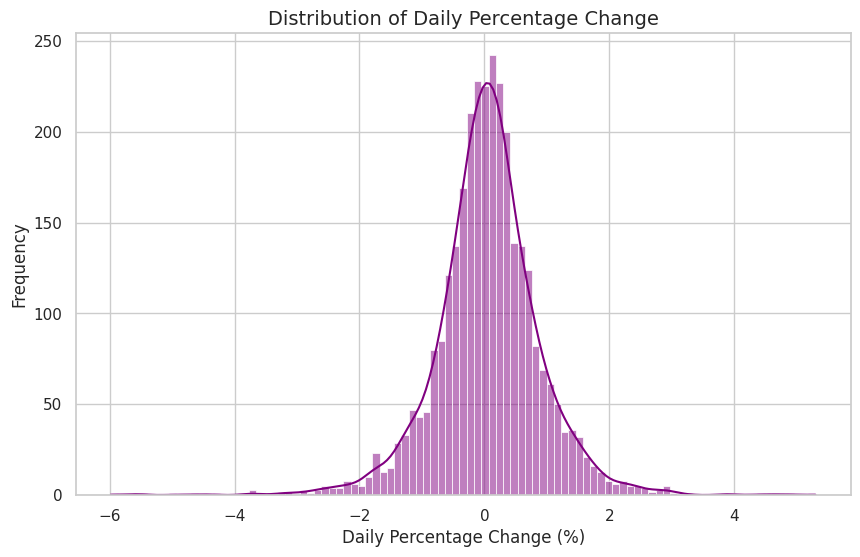

In [29]:
# Chart 4: Distribution of Daily Percentage Change (Chg%)

# This chart helps us understand daily market volatility.
# It shows how frequently gold prices increase or decrease in percentage terms.

plt.figure(figsize=(10,6))  # set figure size

# Histogram with KDE to visualize distribution of daily % change
sns.histplot(df["Chg%"], kde=True, color="purple")

# Chart title and axis labels
plt.title("Distribution of Daily Percentage Change", fontsize=14)
plt.xlabel("Daily Percentage Change (%)")
plt.ylabel("Frequency")

# Display chart
plt.show()

#### **Why this chart is used**

*  This Histogram with KDE is used to understand market volatility.

*  The Chg% (Daily Percentage Change) shows how much the gold price moves up or down each day.

*  Analyzing this helps us understand:

    *  How frequently gold prices increase or decrease

    *  Whether the market is stable or highly volatile

    *  Whether extreme price movements occur

*  This is very important in financial time series analysis.

#### **Insight from the chart**

From the chart we can observe:

*  The distribution is approximately normal (bell-shaped).

*  Most daily price changes lie between: -1% to +1%

*  The center of the distribution is around 0%, meaning gold prices typically have small daily movements.

*  There are few extreme movements reaching around: -6% to +5%

*  These represent rare market shocks.


#### **Business Insight**

**Market Stability Insight**

*  The gold market generally shows low daily volatility, meaning prices move gradually rather than drastically.

*  This is one reason gold is considered a relatively stable investment asset.

**Risk Insight**

*  Occasional large percentage changes indicate market reactions to major events, such as:

    *  Global financial crises

    *  Inflation announcements

    *  Geopolitical tensions

    *  currency fluctuations

*  These events can trigger temporary spikes in volatility.

### **Chart 5: Density Plot of Gold Prices**

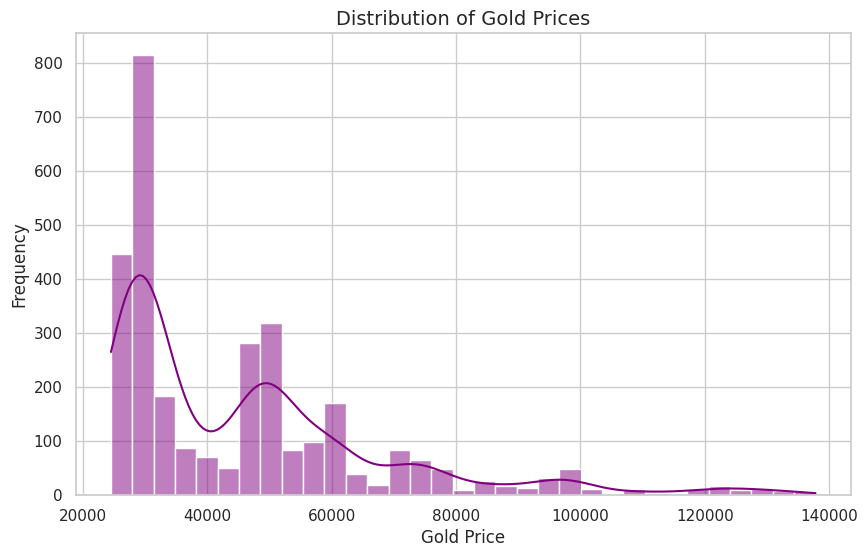

In [ ]:
# Chart 5: Density Plot of Gold Prices

# This chart shows the probability density of gold prices.
# It helps understand where the prices are most concentrated in the dataset.

plt.figure(figsize=(10,6))  # set figure size

# KDE plot for price distribution
sns.kdeplot(df["Price"], fill=True, color="purple")

# Chart title and labels
plt.title("Density Plot of Gold Prices", fontsize=14)
plt.xlabel("Gold Price")
plt.ylabel("Density")

# Display chart
plt.show()

#### **Why this chart is used**

*  A Kernel Density Estimation (KDE) plot is used to visualize the probability density of a continuous variable.

*  Unlike histograms, KDE plots show a smooth distribution curve, which helps identify:

    *  Areas where values are most concentrated

    *  Multiple peaks (price regimes)

    *  Overall shape of the distribution

*  This helps understand how gold prices are spread across different value ranges.

#### **Insight from the chart**

From the density curve we observe:

*  The highest density occurs roughly between: ₹28,000 – ₹35,000 meaning many observations belong to earlier years when prices were lower.

*  A second noticeable density region appears around: ₹45,000 – ₹55,000 which likely corresponds to mid-period gold prices.

*  The long tail extending toward: ₹100,000 – ₹135,000 represents recent years where gold prices increased significantly.

*  The distribution again confirms right skewness, meaning high prices occur less frequently but extend the distribution.

#### **Business Insight**

**Market Trend Insight**

*  The density peaks indicate that gold prices have existed in different price regimes over time.

*  This reflects long-term price appreciation, likely driven by:

    *  inflation

    *  global economic uncertainty

    *  increased demand for safe-haven assets.

**Investment Insight**

The right-skewed distribution suggests that gold prices have steadily moved toward higher ranges over time, reinforcing its reputation as a long-term value-preserving asset.

### **Chart**

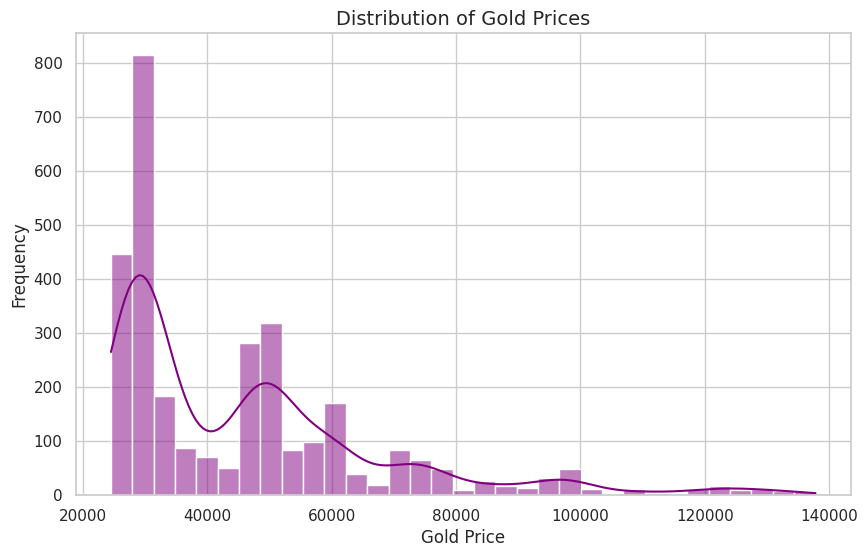

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

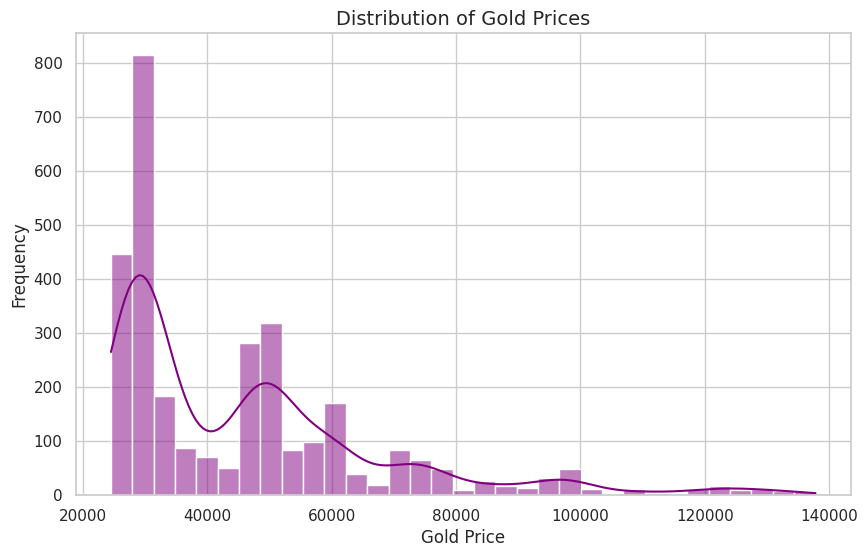

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

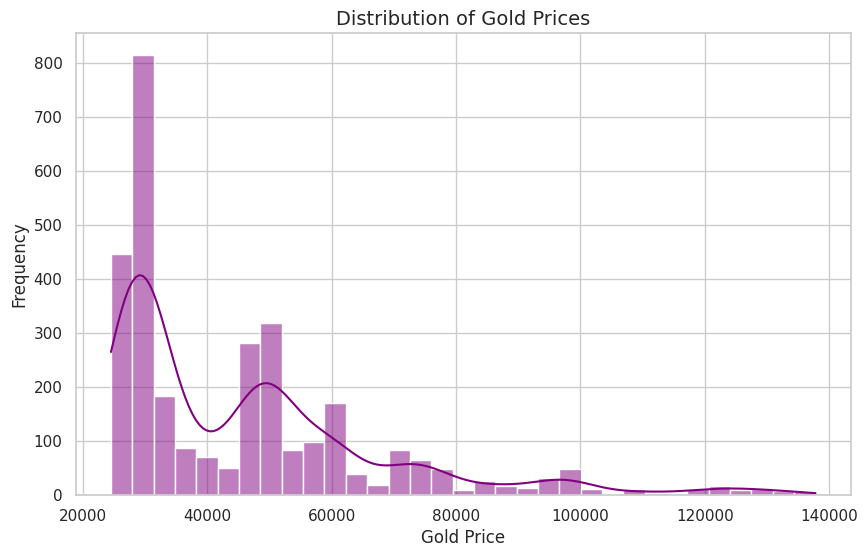

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

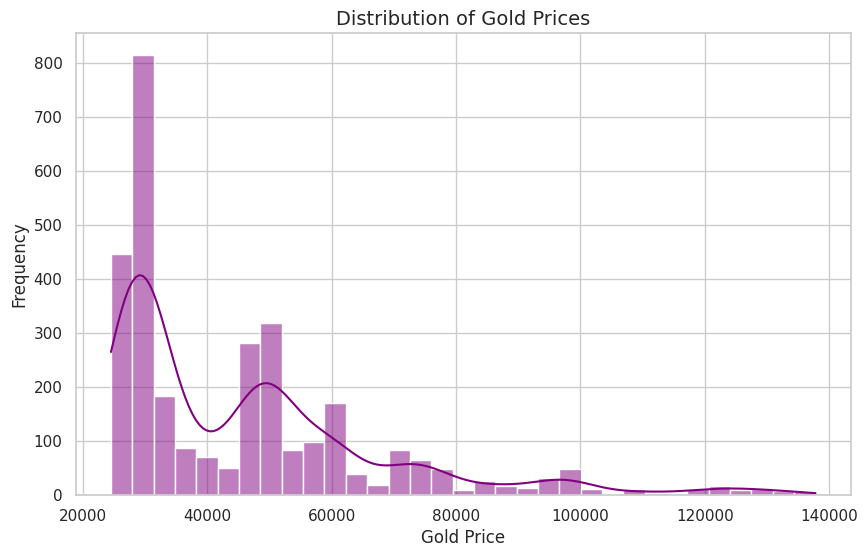

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

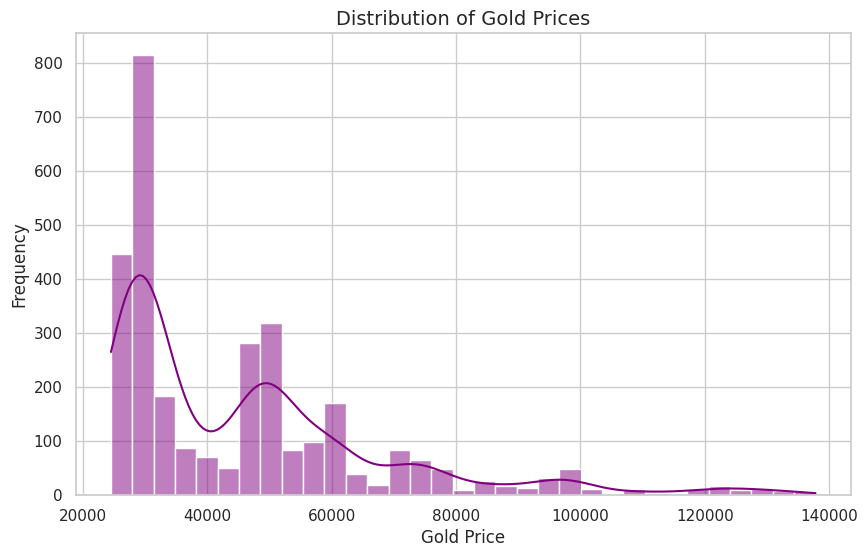

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

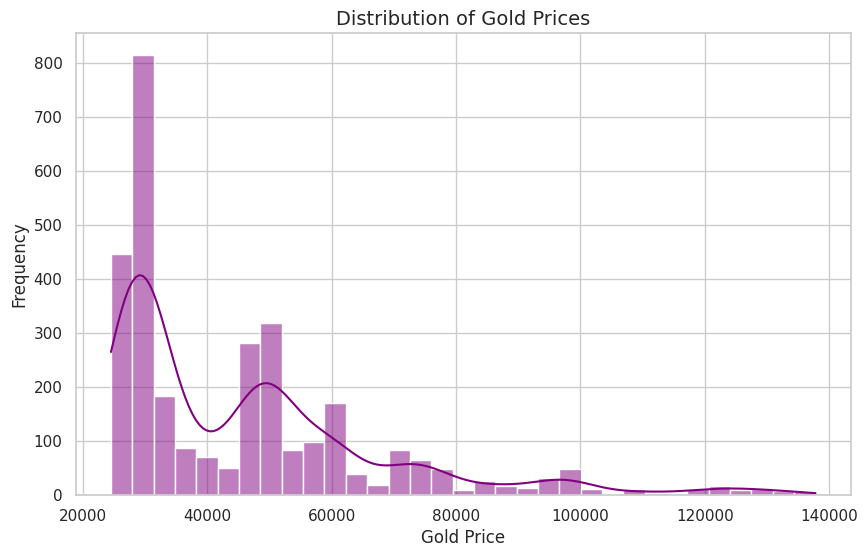

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

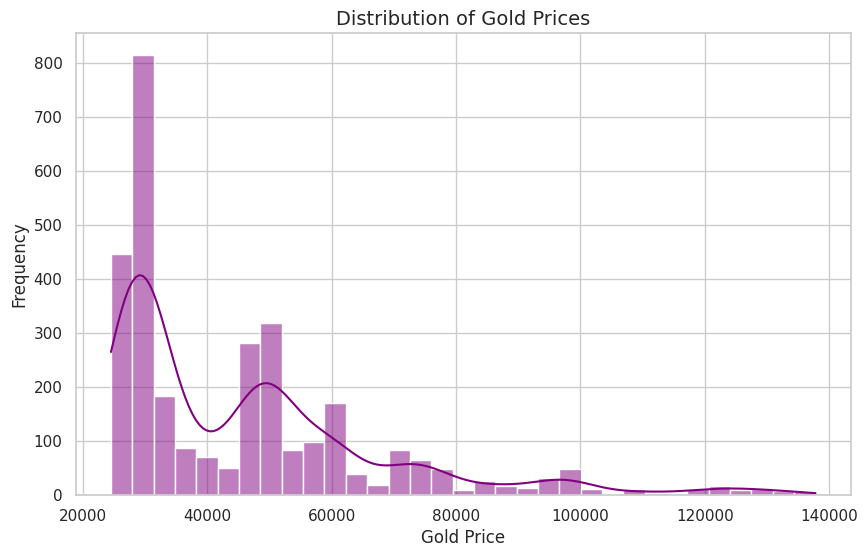

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

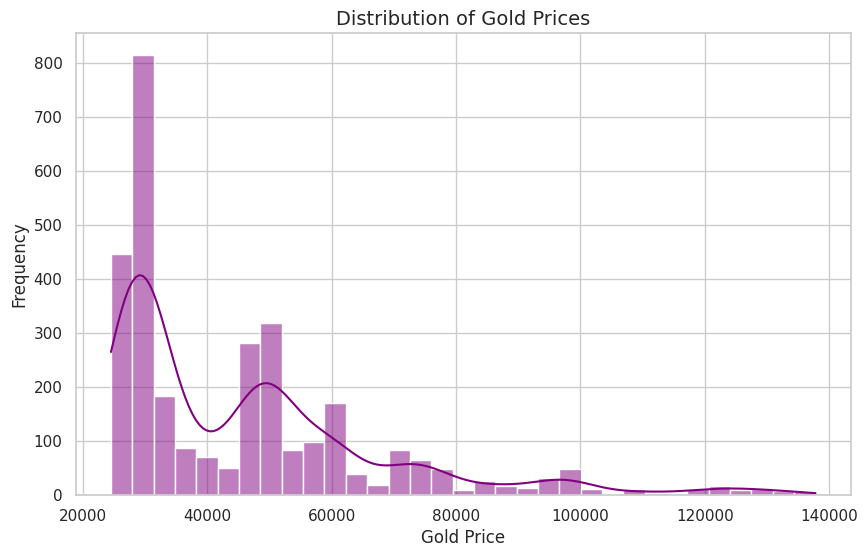

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

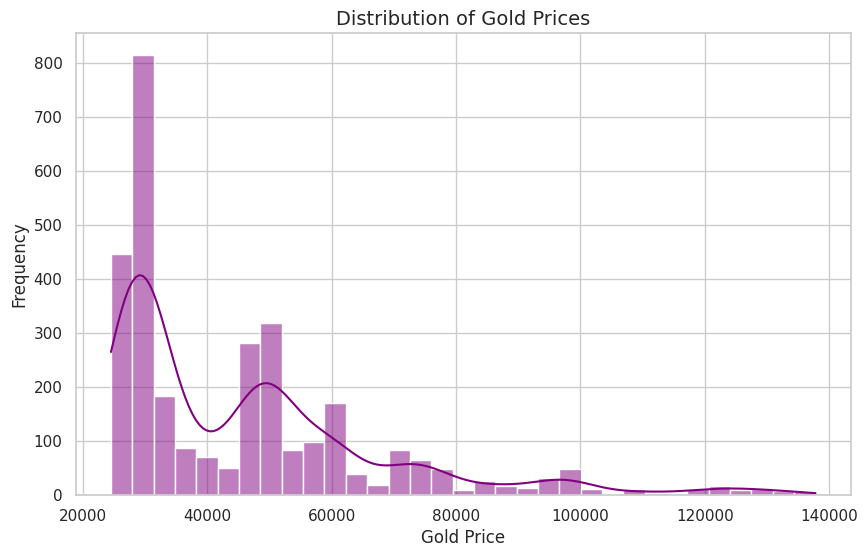

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

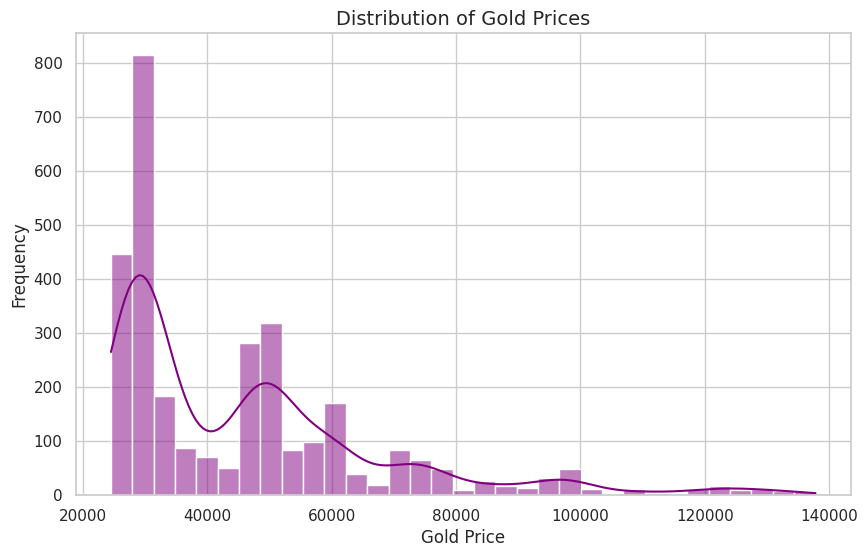

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

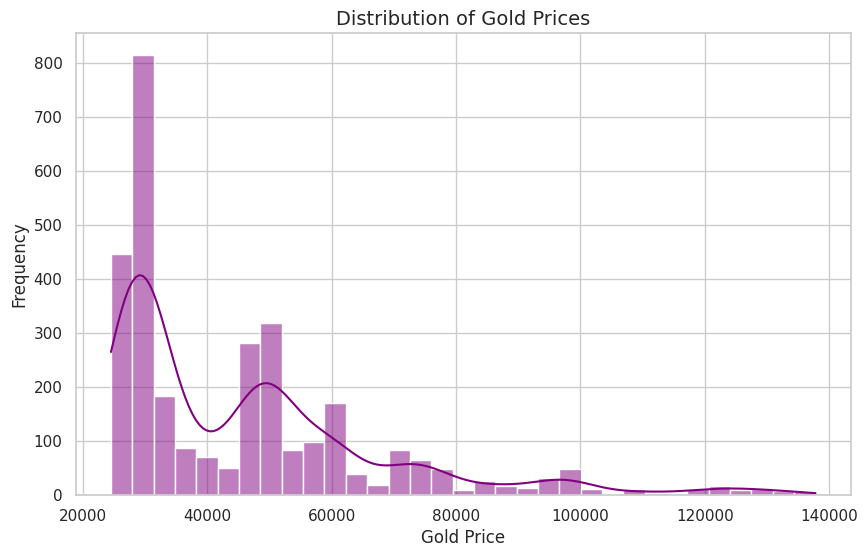

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

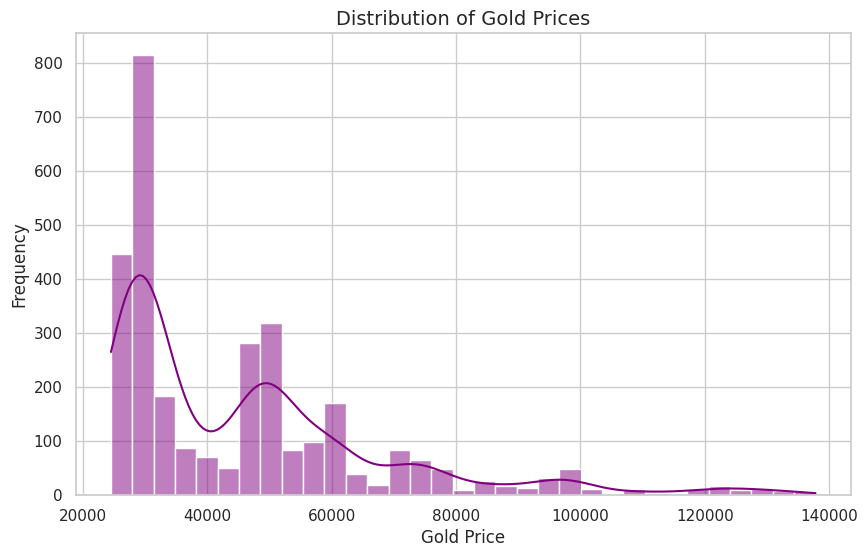

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

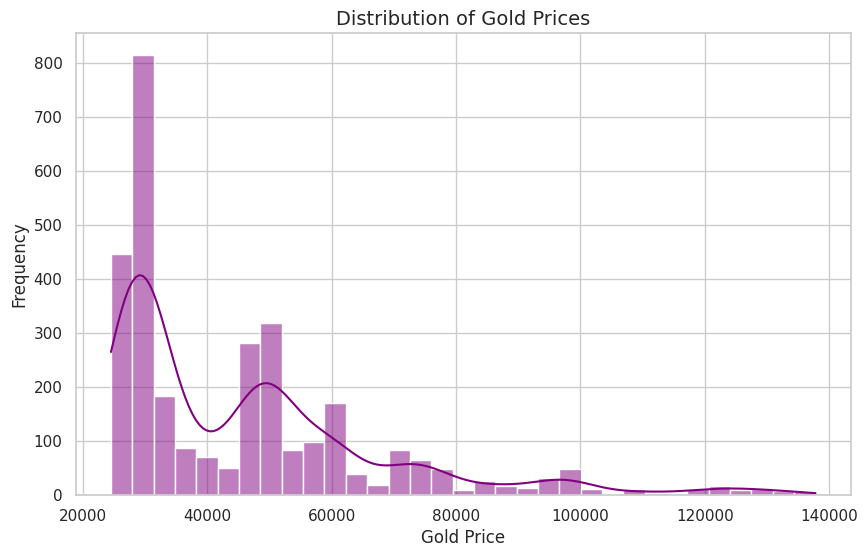

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

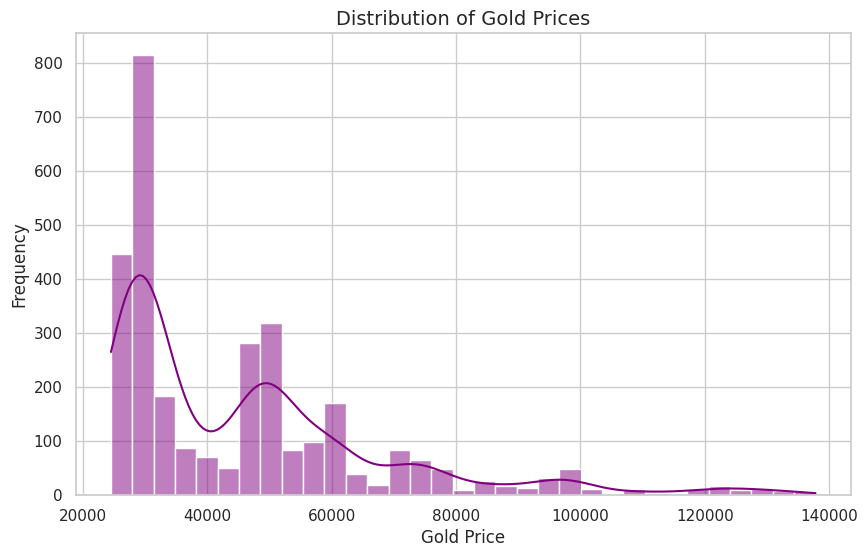

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

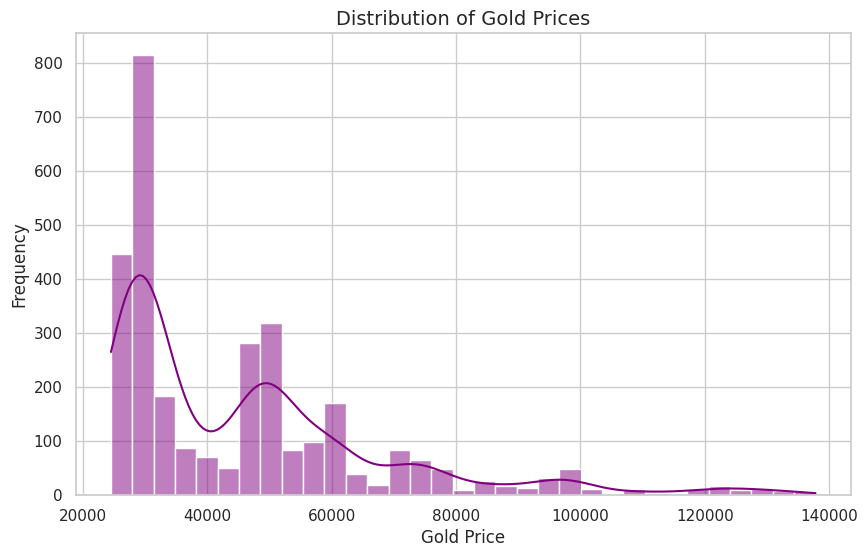

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

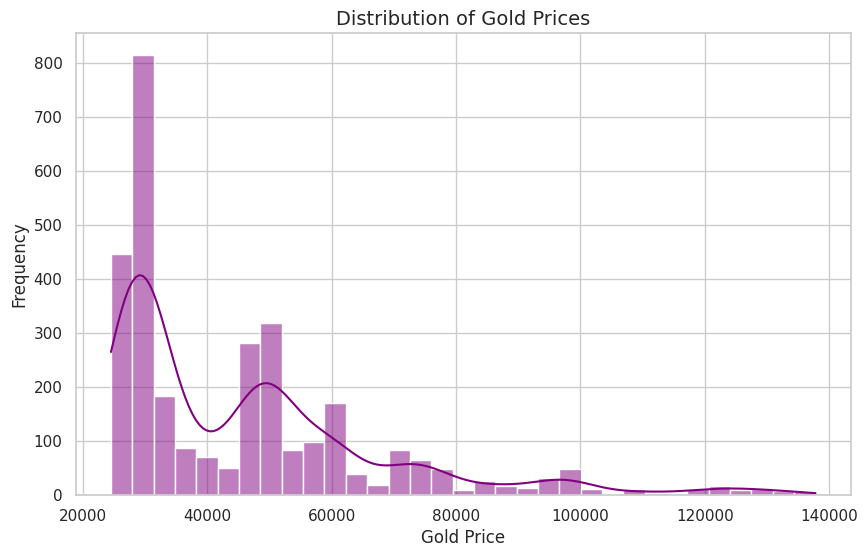

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

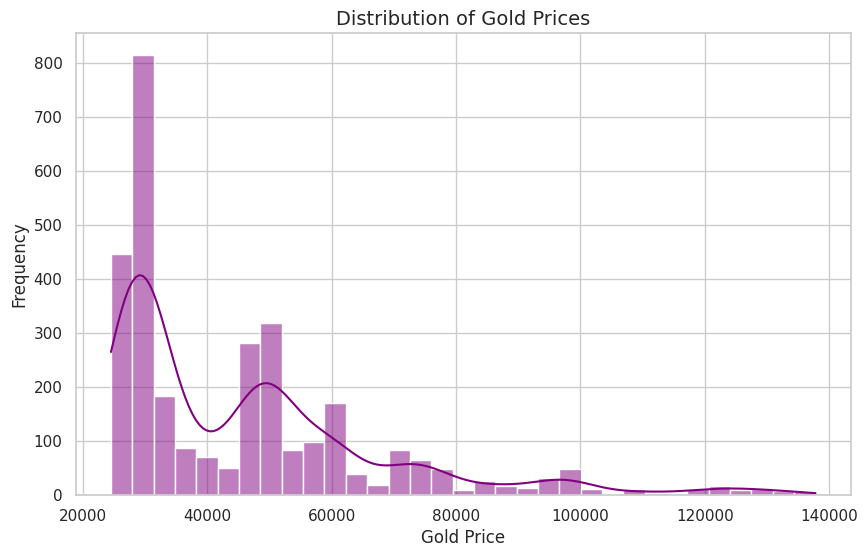

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

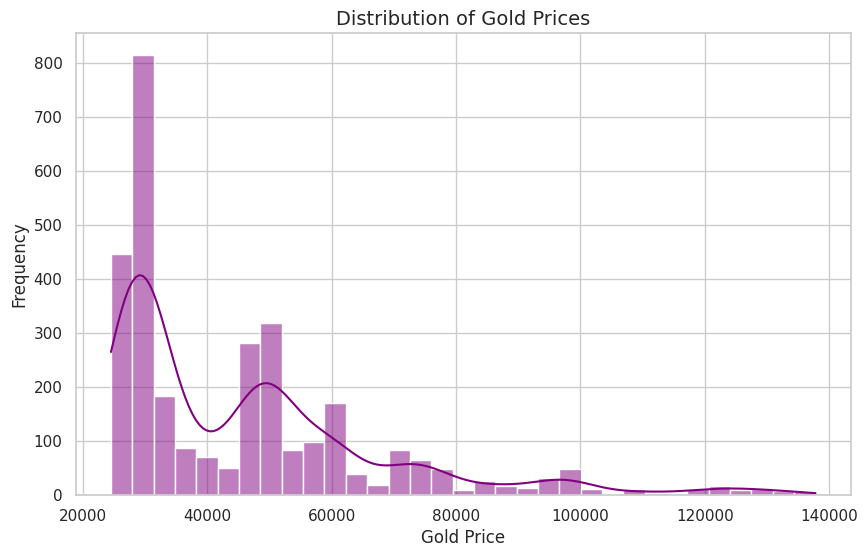

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

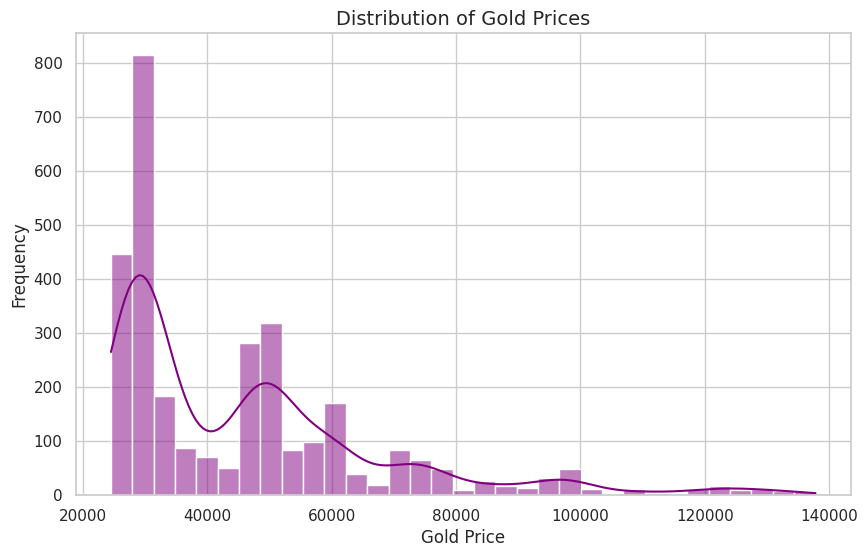

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

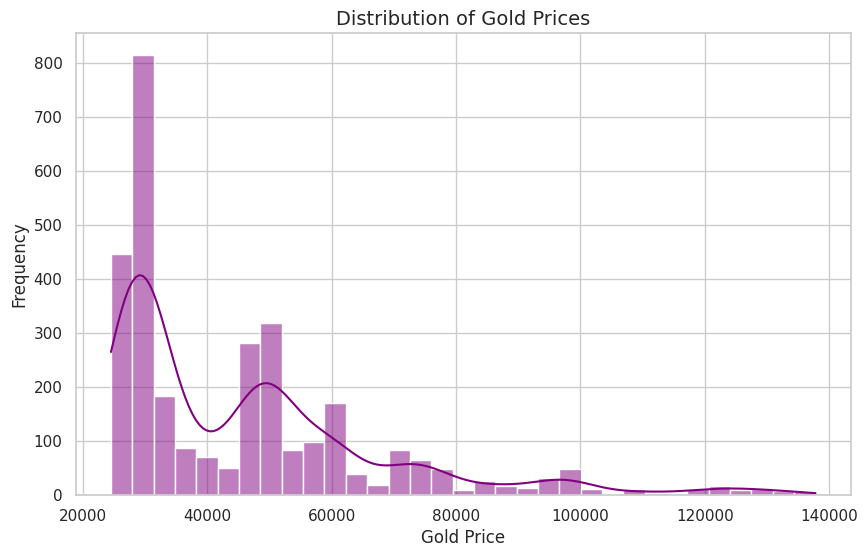

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

### **Chart**

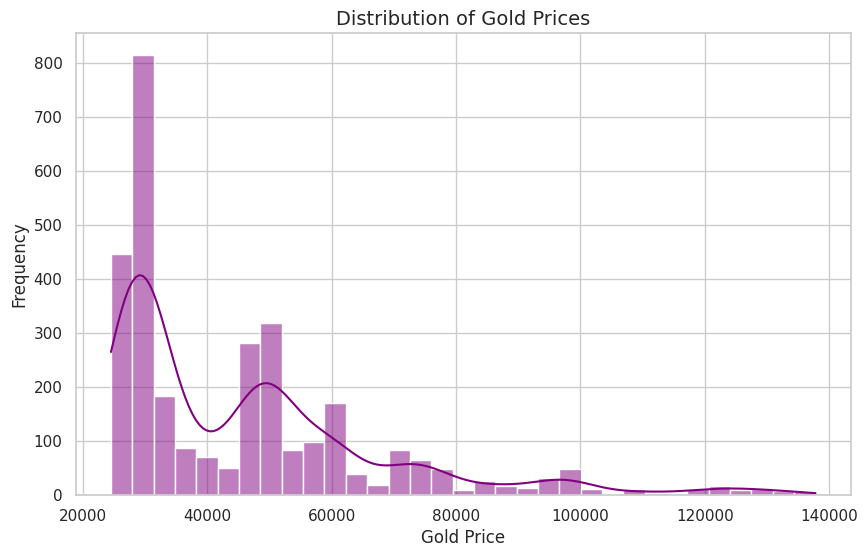

#### **Why this chart is used**

#### **Insight from the chart**

#### **Business Insight**

# **Hypothesis Testing**

# **Data Preprocessing**

# **Implementing Machine Learning Models**

# **Final Model**

# **Conclusion**